--- ANTRENARE ONE-CLASS SVM PE GPU (PyTorch Aliniat) ---
Date partajate cu succes: Train_Normal=25980, Test_Total=13559
Procesare finalizată pe GPU în 0.07 secunde!

Raport clasificare:
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95     11161
        Atac       0.78      0.79      0.79      2398

    accuracy                           0.92     13559
   macro avg       0.87      0.87      0.87     13559
weighted avg       0.92      0.92      0.92     13559

AUC: 0.9694


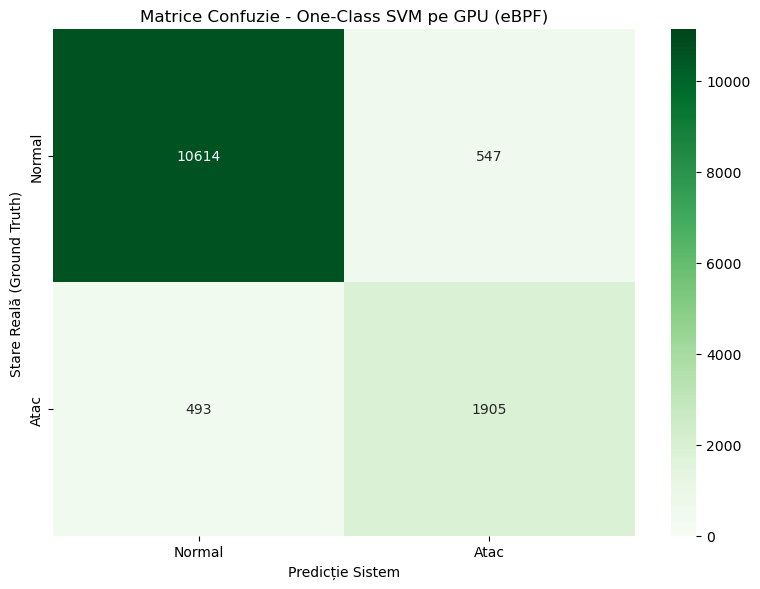

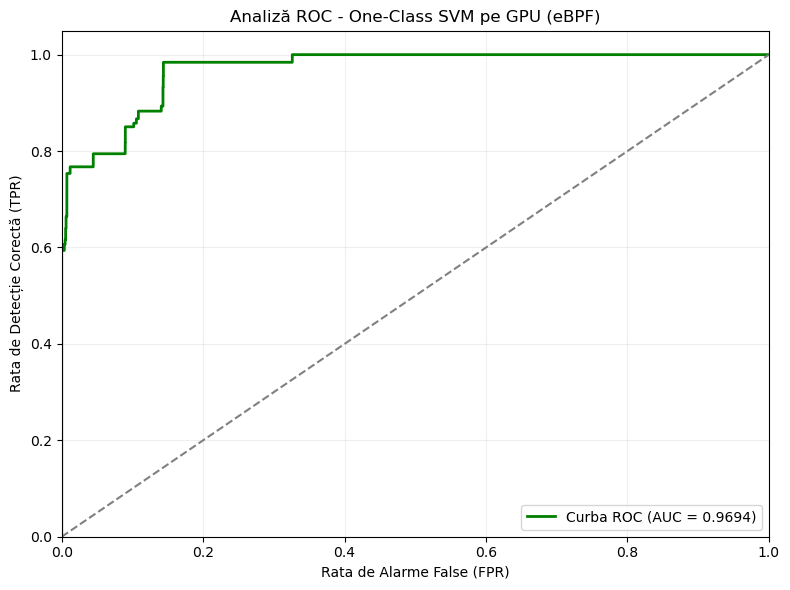


Toate rezultatele au fost salvate în: D:\disertatie\eBPF_WSL\rezultate_eBPF\One_Class_SVM


In [3]:
import pandas as pd
import numpy as np
import torch
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_path = 'dataset_eBPF.csv'
rezultate_path = r'D:\disertatie\eBPF_WSL\rezultate_eBPF\One_Class_SVM'
os.makedirs(rezultate_path, exist_ok=True)

print("--- ANTRENARE ONE-CLASS SVM PE GPU (PyTorch Aliniat) ---")
df = pd.read_csv(dataset_path)

X_raw_np = df[['pid', 'uid', 'gid', 'len', 'hour']].values
y_raw_np = df['label'].values

indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(len(df) * 0.7)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train_np = X_raw_np[train_indices][y_raw_np[train_indices] == 0]
X_test_np = X_raw_np[test_indices]
y_test_np = y_raw_np[test_indices]

rng = np.random.default_rng(42)
X_train_np = X_train_np + rng.normal(0, 1e-5, size=X_train_np.shape)
X_test_np = X_test_np + rng.normal(0, 1e-5, size=X_test_np.shape)

X_train = torch.tensor(X_train_np, dtype=torch.float32, device=device)
X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long, device=device)

print(f"Date partajate cu succes: Train_Normal={X_train.shape[0]}, Test_Total={X_test.shape[0]}")

mean = X_train.mean(dim=0)
std = X_train.std(dim=0)
std[std == 0] = 1.0

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

nu = 0.05
gamma = 1.0 / X_train_scaled.shape[1]

torch.cuda.synchronize()
start_time = time.time()

K_train_self = torch.cdist(X_train_scaled, X_train_scaled, p=2) ** 2
K_train_self = torch.exp(-gamma * K_train_self)

gamma_dist = torch.mean(K_train_self, dim=1)
threshold_idx = int(nu * X_train_scaled.shape[0])
rho = torch.sort(gamma_dist)[0][threshold_idx]

torch.cuda.synchronize()
train_time = time.time() - start_time
print(f"Procesare finalizată pe GPU în {train_time:.2f} secunde!")

with torch.no_grad():
    K_test = torch.cdist(X_test_scaled, X_train_scaled, p=2) ** 2
    K_test = torch.exp(-gamma * K_test)
    
    test_scores = torch.mean(K_test, dim=1) - rho
    
    y_pred = torch.where(test_scores < 0, 1, 0).cpu().numpy()
    decision_scores = test_scores.cpu().numpy()

y_test = y_test_tensor.cpu().numpy()
y_scores = -decision_scores

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Atac'])

print("\nRaport clasificare:")
print(report)
print(f"AUC: {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
full_report_text = f"AUC: {roc_auc:.4f}\nTimp Antrenare: {train_time:.2f}s\n\nMatrice Confuzie:\n{cm}\n\n{report}"
with open(os.path.join(rezultate_path, 'raport_ebpf_ocsvm_gpu.txt'), 'w') as f:
    f.write(full_report_text)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', vmin=0, vmax=11134, xticklabels=['Normal', 'Atac'], yticklabels=['Normal', 'Atac'])
plt.title('Matrice Confuzie - One-Class SVM pe GPU (eBPF)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ebpf_ocsvm_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('Rata de Detecție Corectă (TPR)')
plt.xlabel('Rata de Alarme False (FPR)')
plt.title('Analiză ROC - One-Class SVM pe GPU (eBPF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ebpf_ocsvm_gpu.png'), dpi=300)
plt.show()

print(f"\nToate rezultatele au fost salvate în: {rezultate_path}")